In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [27]:
df = pd.read_csv("../data/retail_sales.csv")

In [28]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [29]:
df.shape

(1000, 9)

### Dataset Overview
The dataset contains customer purchases and retail sales information.
There are **1000 rows** and **9 columns** in the dataset.

In [30]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


### Dataset Information
#### Observations
- There are **5 numerical columns** and **4 categorical columns**.
- No missing values are present in the dataset.
- The **Date** column is currently stored as a string and will be converted to datetime format for time series analysis.

In [32]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Observation
There are no missing values.

In [33]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [34]:
df.mean(numeric_only=True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [35]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [36]:
df.mode().iloc[0]

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object

In [37]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

### Descriptive Statistics Analysis

#### Observations

The descriptive statistics provide insights into the central tendency and variability of the numerical variables in the retail sales dataset.

#### Mean
- The average customer age is **41.39 years**.
- Customers purchase an average of **2.51 items** per transaction.
- The average price per unit is **179.89**.
- The average total transaction amount is **456.00**.

#### Median
- The median customer age is **42 years**, indicating that half of the customers are younger than 42 and half are older.
- The median quantity purchased is **3 units**.
- The median price per unit is **50**.
- The median total transaction amount is **135**.

#### Mode
- The most frequent customer age is **43 years**.
- The most common gender is **Female**.
- The most frequently purchased product category is **Clothing**.
- The most common quantity purchased is **4 units**.
- The most frequent price per unit is **50**.

#### Standard Deviation
- The standard deviation of **Age (13.68)** indicates a moderate variation in customer ages.
- The **Quantity (1.13)** has a low standard deviation, showing that customers generally purchase a similar number of items.
- The **Price per Unit (189.68)** has a high standard deviation, indicating significant variation in product prices.
- The **Total Amount (559.99)** also has a high standard deviation, suggesting considerable variation in transaction values.

### Summary

The dataset shows that customers are primarily middle-aged, with females being the most frequent shoppers. Clothing is the most commonly purchased product category. While customers generally buy a similar quantity of items, transaction values vary significantly due to differences in product prices.

In [38]:
df["Date"] = pd.to_datetime(df["Date"])

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [40]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create Month column
df["Month"] = df["Date"].dt.to_period("M")

# Find the last month in the dataset
last_month = df["Month"].max()

# Remove the last month (assumed incomplete)
df_complete = df[df["Month"] != last_month]

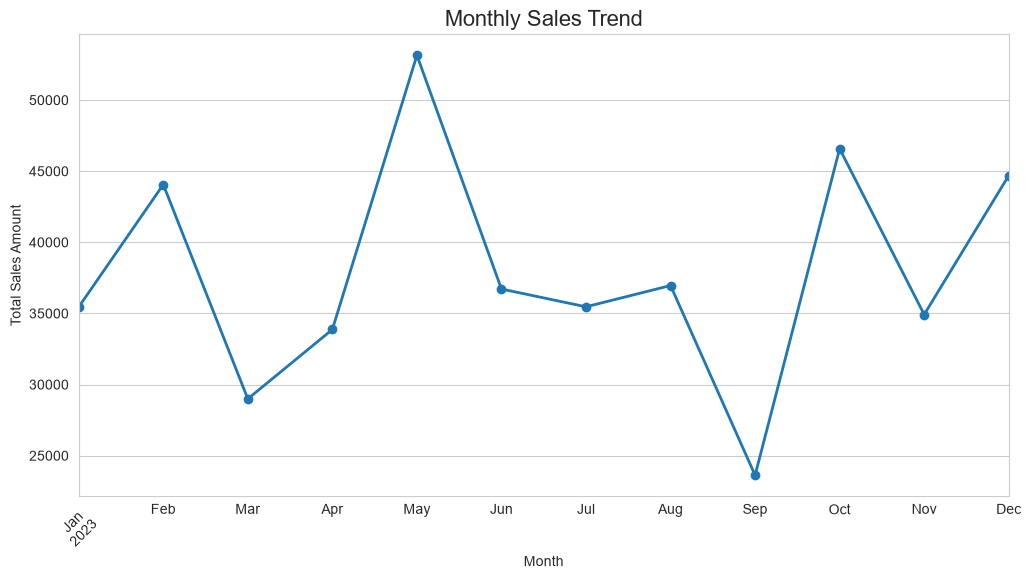

In [41]:
# Calculate monthly sales
monthly_sales = df_complete.groupby("Month")["Total Amount"].sum()

# Plot
plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o', linewidth=2)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Monthly Sales Trend Analysis
#### Observation
The monthly sales trend shows that sales fluctuate throughout the year.
#### Key Findings
- Sales reached their highest value in **May 2023**.
- High sales were also observed in **October** and **December**.
- **March** and **September** recorded comparatively lower sales.
- The incomplete data for **January 2024** was excluded to ensure an accurate month-to-month comparison.
### Business Insight
The business should increase inventory and marketing efforts before high-performing months such as **May**, **October**, and **December**. Additional promotional campaigns can be introduced during low-performing months to improve sales performance.

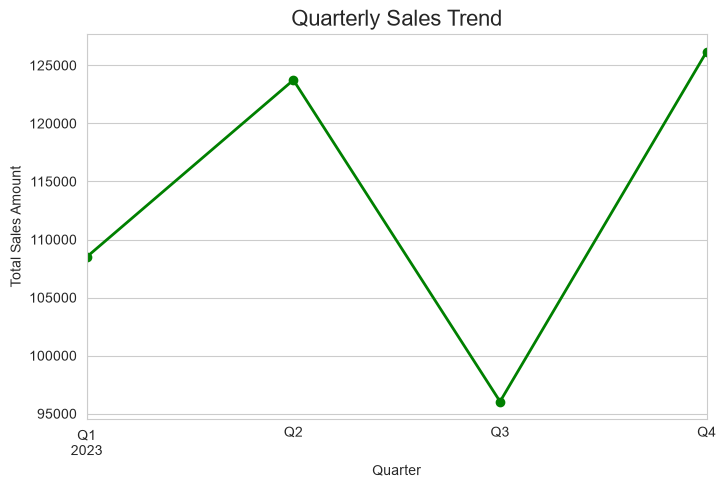

In [42]:
# Create Quarter column
df_complete["Quarter"] = df_complete["Date"].dt.to_period("Q")

# Calculate quarterly sales
quarterly_sales = df_complete.groupby("Quarter")["Total Amount"].sum()

# Plot
plt.figure(figsize=(8,5))

quarterly_sales.plot(marker='o', linewidth=2, color='green')

plt.title("Quarterly Sales Trend", fontsize=16)
plt.xlabel("Quarter")
plt.ylabel("Total Sales Amount")

plt.grid(True)

plt.show()

### Quarterly Sales Trend Analysis
#### Observation
The quarterly sales trend provides an overview of the total sales performance across all four quarters of 2023.
#### Key Findings
- **Q4 (October–December)** recorded the **highest total sales**, indicating the strongest business performance during the year.
- **Q2 (April–June)** achieved the second-highest sales, showing consistent customer demand during this period.
- **Q3 (July–September)** recorded the **lowest sales**, suggesting a decline in customer purchases compared to other quarters.
- **Q1 (January–March)** showed moderate sales performance and served as a stable start to the year.
### Business Insight
The business should maintain sufficient inventory and increase promotional activities before **Q4**, as it is the highest-performing quarter. Since **Q3** recorded the lowest sales, targeted discounts, festive offers, or marketing campaigns can be introduced during this period to improve customer engagement and boost revenue.
### Conclusion
The quarterly analysis reveals seasonal variations in customer purchasing behavior. Understanding these trends enables businesses to improve inventory planning, marketing strategies, and sales forecasting, ultimately leading to better business performance.

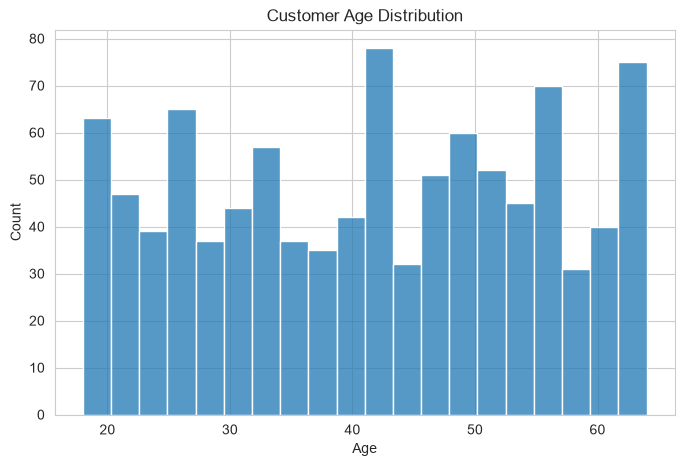

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Customer Age Distribution")
plt.show()

### Customer Age Distribution
#### Observation
The age distribution indicates that customers belong to a wide range of age groups, with the majority falling between **40 and 60 years**. This suggests that middle-aged customers form a significant portion of the customer base, making them an important target segment for marketing and promotional activities.

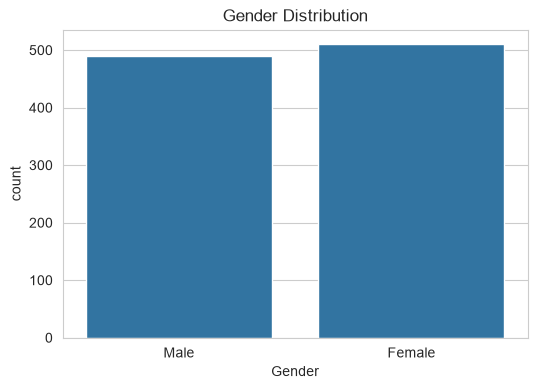

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

### Gender Distribution
#### Observation
The gender distribution is nearly balanced, with **female customers slightly outnumbering male customers**. This indicates that the business attracts customers from both genders, suggesting opportunities for inclusive marketing strategies and product offerings.

In [45]:
# Calculate total revenue for each product category
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

# Display revenue
print(category_revenue)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


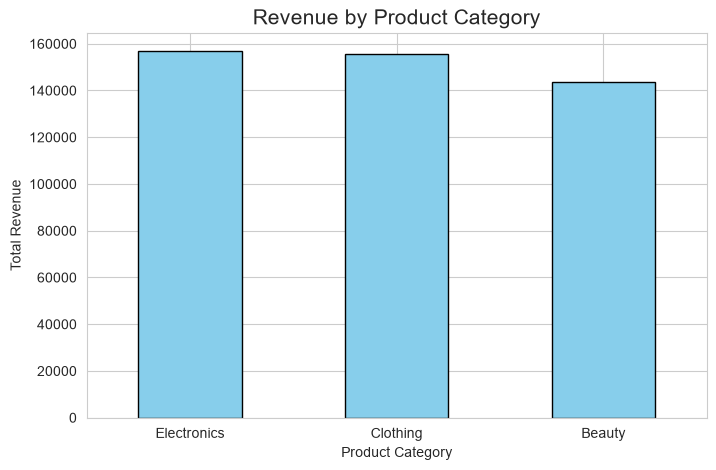

In [46]:
plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Revenue by Product Category", fontsize=15)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

### Revenue by Product Category
#### Observation
The bar chart shows the total revenue generated by each product category. It helps identify the highest-performing categories and those contributing less to overall sales.
### Business Insight
The business should focus on promoting high-revenue product categories while developing strategies to improve the sales of lower-performing categories.

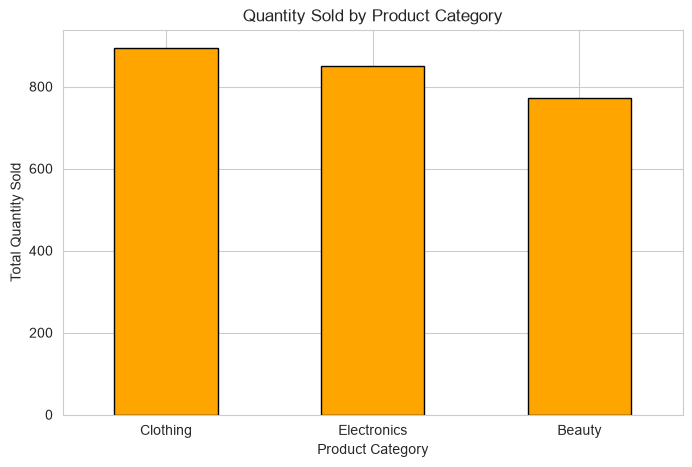

In [47]:
category_quantity = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
category_quantity.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=0)

plt.show()

### Quantity Sold by Product Category
#### Observation
This chart displays the total quantity sold for each product category. Categories with higher quantities indicate greater customer demand and purchasing frequency.
### Business Insight
High-demand categories should be adequately stocked to avoid inventory shortages, while lower-demand categories may require promotional offers to increase sales.

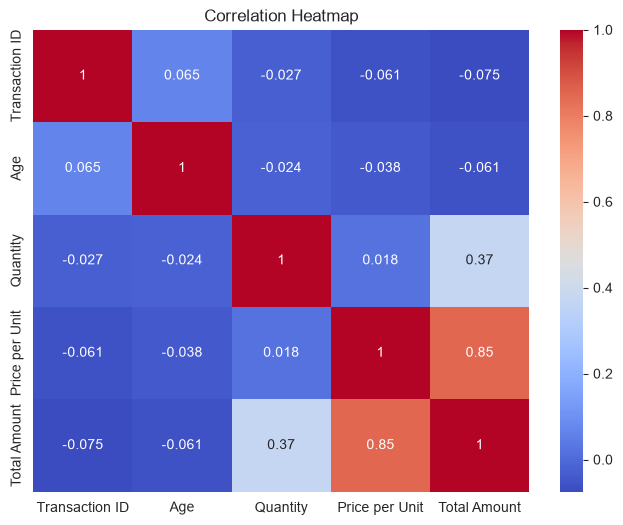

In [48]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Correlation Heatmap
#### Observation
The heatmap shows the relationship between numerical variables. **Price per Unit** and **Total Amount** have a strong positive correlation (**0.85**), indicating that higher-priced products generally result in higher transaction amounts. **Quantity** has a moderate positive correlation (**0.37**) with **Total Amount**, while other variables show weak or negligible correlations.

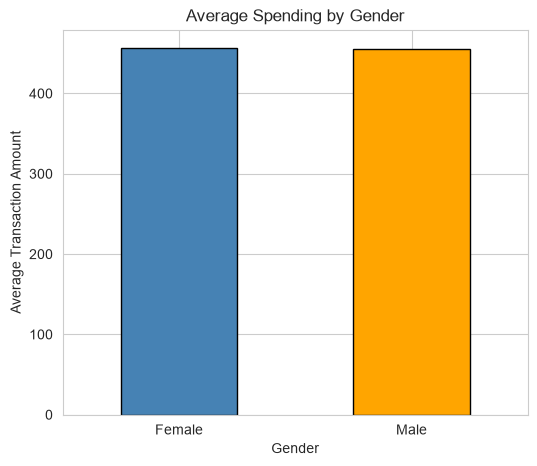

In [49]:
# Calculate average spending by gender
gender_sales = df.groupby("Gender")["Total Amount"].mean()

plt.figure(figsize=(6,5))

gender_sales.plot(kind="bar", color=["steelblue", "orange"], edgecolor="black")

plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Transaction Amount")

plt.xticks(rotation=0)

plt.show()

### Average Spending by Gender
#### Observation
The chart compares the average transaction amount of male and female customers. It helps identify spending patterns across different customer groups and supports targeted marketing strategies.

### Conclusion
#### Summary
This Exploratory Data Analysis (EDA) examined retail sales data to understand customer behavior, sales trends, and product performance. The analysis included descriptive statistics, time series analysis, customer demographics, product category performance, and correlation analysis.
### Business Recommendations
1. **Increase inventory during high-sales periods** such as Q4 and peak months to meet customer demand.
2. **Focus marketing campaigns on high-performing product categories** to maximize revenue while promoting lower-performing categories through discounts and special offers.
3. **Develop customer-focused promotional strategies** for different age groups and both genders to improve customer engagement and sales.
4. **Review pricing strategies**, as the strong positive correlation between Price per Unit and Total Amount suggests pricing significantly impacts revenue.
5. **Use sales trend analysis for forecasting** to improve inventory planning and business decision-making.